## **full_opt_forward.py -- Demonstrate full imaging pipeline** ##

Load Gerchberg-Saxton constructed phase masks for a metalens singlet and metalens array to test imaging pipeline for spatially invariant/varying modalities.

full_opt_forward imaging module executes the following:
- Use ASM propagation to calculate PSFs (single on-axis plane wave or multiple plane waves from sparse field points)
- Window PSF for smaller calculation for SV modality
- Convolve PSF with a batch of images (spatially invariant or varying)
- Crop and downsample captured images (singlet or lens array)
- Subtract negative from positive channels to form feature maps

For each physical configuration (singlet or array), comparison of spatially invariant and varying convolution is shown. HFOV for all lenses are 7 deg.

In [19]:
import math
import torch
import matplotlib.pyplot as plt
import numpy as np

import sys
sys.path.append("asm_full_opt")
from phase_mask import PhaseMask
from asm_prop import ASMPropagator
from pixel_map import PixelMap
from psf_conv import PSFConv
from generate_waves_sv import GenerateWaves
from process_psf_sv import PSFProcessor
from full_opt_forward import FullOptForward
from im_postprocess import PostProcess
import config

UM = 1E-6

## Load phase masks ##

singlet_phase shape: (1, 459, 459)
array_phase shape: (16, 115, 115)


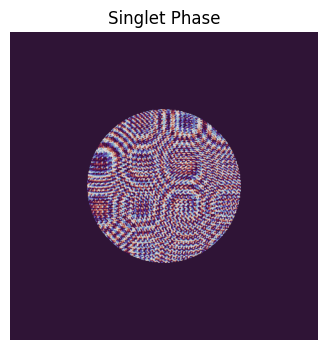

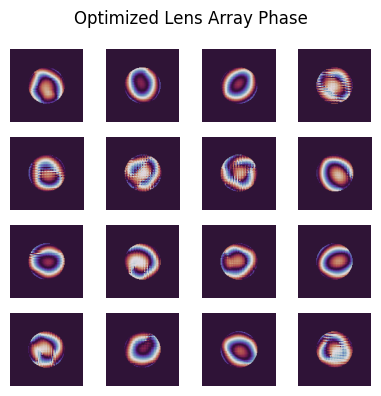

In [20]:
import os
file_path = os.path.abspath("store_outputs/MNIST_7x7_multiplex/MNIST_8x7x7_phase_init.pt")
singlet_phase_init = torch.load(file_path, map_location="cpu")

file_path = os.path.abspath("store_outputs/MNIST_7x7_array/MNIST_8x7x7_phase_init.pt")
array_phase_init = torch.load(file_path, map_location="cpu")

print("singlet_phase shape:", tuple(singlet_phase_init.shape))
print("array_phase shape:", tuple(array_phase_init.shape))

# Plot singlet
plt.figure(figsize=(4,4))
plt.imshow(singlet_phase_init[0].numpy(), cmap="twilight", origin="lower")
plt.title("Singlet Phase")
plt.axis("off")
plt.show()
# Plot array phases (4 per row)
K = array_phase_init.shape[0]
cols = 4
rows = math.ceil(K / cols)
fig, axes = plt.subplots(rows, cols, figsize=(1*cols, 1*rows))
axes = axes.flatten()
for i in range(K):
    axes[i].imshow(array_phase_init[i].numpy(), cmap="twilight", origin="lower")
    # axes[i].set_title(f"{i}", fontsize=9)
    axes[i].axis("off")
# Hide unused axes
for i in range(K, len(axes)):
    axes[i].axis("off")
fig.suptitle("Optimized Lens Array Phase")
plt.tight_layout()
plt.show()

## Load some target objects ##

Loaded batch: torch.Size([10, 28, 28])
Labels (first 10): [3, 1, 1, 0, 4, 9, 2, 0, 0, 2]


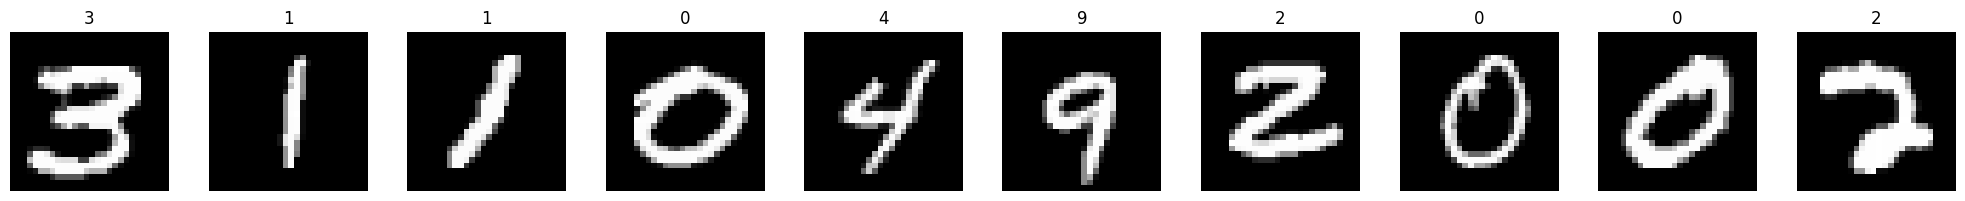

In [21]:
from torchvision.datasets import MNIST
ds = MNIST(root="./data", train=True, download=True)
N_batch = 10
idx0 = 111   # starting index
objs = []
labels = []
for i in range(N_batch):
    x_pil, y = ds[idx0 + i]
    objs.append(torch.from_numpy(np.array(x_pil)).float() / 255.0)
    labels.append(y)
objs = torch.stack(objs, dim=0)   
print("Loaded batch:", objs.shape)
print("Labels (first 10):", labels[:10])
fig, axes = plt.subplots(1, N_batch, figsize=(2*N_batch, 2))
for i in range(N_batch):
    axes[i].imshow(objs[i].numpy(), cmap="gray")
    axes[i].set_title(labels[i])
    axes[i].axis("off")
plt.tight_layout()
plt.show()

In [22]:
config.GRID_N = 459
config.HFOV=7
config.LENS_D=80*UM
config.PSF_WINDOW_N=275
config.SV=False

In [23]:
asm = ASMPropagator(config)
pm = PixelMap(config, asm.X, asm.Y)
waves = GenerateWaves(config, pm, X=asm.X, Y=asm.Y)
processor = PSFProcessor(config)
conv = PSFConv(config, pm, processor, asm.X, asm.Y)

file_path = os.path.abspath("store_outputs/MNIST_7x7_multiplex/MNIST_8x7x7_target_psf_centers.pt")
centers = torch.load(file_path, map_location="cpu")
pp = PostProcess(config, pixel_map=pm, centers=centers, X=asm.X, Y=asm.Y, mode="multiplex")

singlet_phase = PhaseMask(
    config,
    init="custom",
    custom=singlet_phase_init,
    X=asm.X,
    Y=asm.Y,    
)

imager = FullOptForward(config, singlet_phase, asm, conv, pp, pm, waves, processor)


## 1) Singlet, Shift Invariant PSF ##

images shape: torch.Size([10, 1, 459, 459])


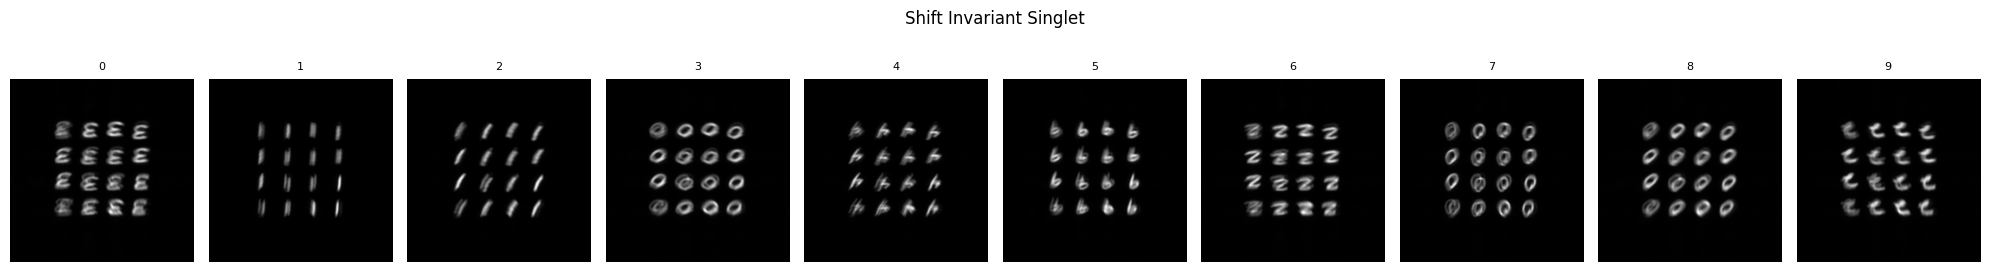

In [24]:
images = imager.optical_forward(objs)

print("images shape:", images.shape)
fig, axes = plt.subplots(1, 10, figsize=(20, 3))
for i in range(10):
    axes[i].imshow(images[i, 0].detach().cpu().numpy().T, cmap="gray", origin="lower")
    axes[i].set_title(f"{i}", fontsize=8)
    axes[i].axis("off")
plt.suptitle("Shift Invariant Singlet")
plt.tight_layout()
plt.show()

fm shape: torch.Size([10, 8, 28, 28])


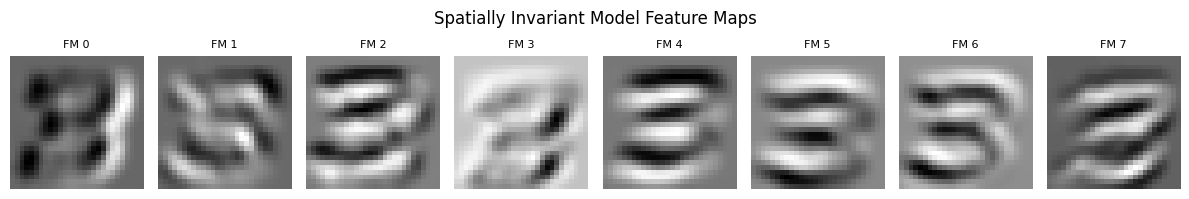

In [25]:
fm = imager.img2fm(images)
print("fm shape:", fm.shape)

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    axes[i].imshow(fm[0, i].detach().cpu().numpy(), cmap="gray")
    axes[i].set_title(f"FM {i}", fontsize=8)
    axes[i].axis("off")
plt.suptitle("Spatially Invariant Model Feature Maps")
plt.tight_layout()
plt.show()

## 2) Singlet, Spatially varying PSF ##

images shape: torch.Size([10, 1, 459, 459])


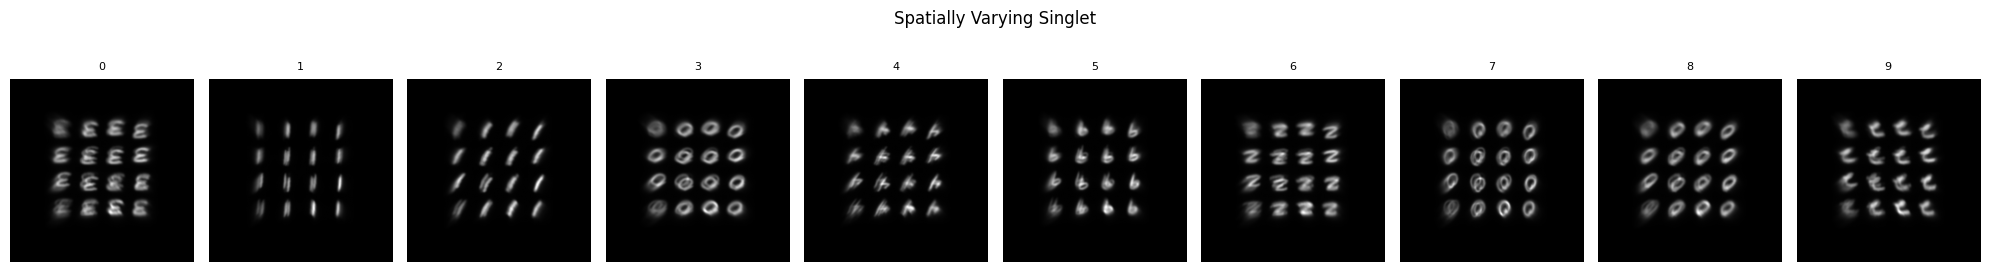

In [26]:
imager.config.SV=True
images_sv = imager.optical_forward(objs)

print("images shape:", images.shape)
fig, axes = plt.subplots(1, 10, figsize=(20, 3))
for i in range(10):
    axes[i].imshow(images_sv[i, 0].detach().cpu().numpy().T, cmap="gray", origin="lower")
    axes[i].set_title(f"{i}", fontsize=8)
    axes[i].axis("off")
plt.suptitle("Spatially Varying Singlet")
plt.tight_layout()
plt.show()

fm shape: torch.Size([10, 8, 28, 28])


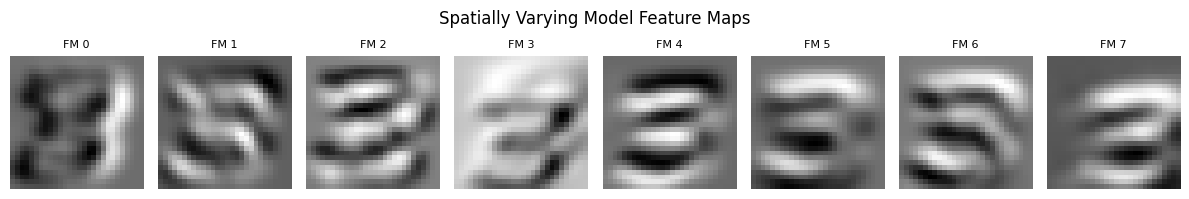

In [27]:
fm_sv = imager.img2fm(images_sv)
print("fm shape:", fm_sv.shape)

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    axes[i].imshow(fm_sv[0, i].detach().cpu().numpy(), cmap="gray")
    axes[i].set_title(f"FM {i}", fontsize=8)
    axes[i].axis("off")
plt.suptitle("Spatially Varying Model Feature Maps")
plt.tight_layout()
plt.show()

# Singlet -- difference between SI and SV ##

diff shape: torch.Size([10, 1, 459, 459])


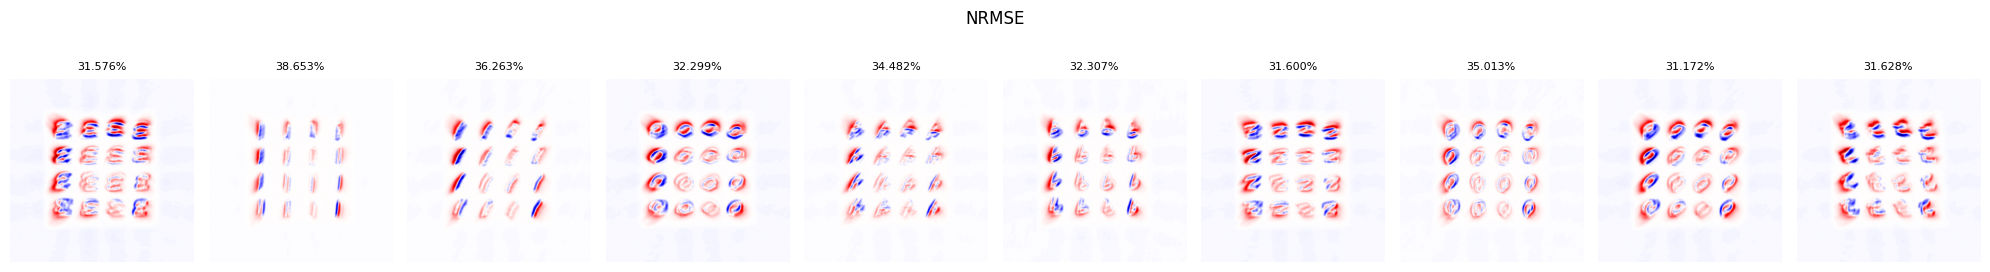

In [28]:
diff = images_sv - images
print("diff shape:", diff.shape)
fig, axes = plt.subplots(1, 10, figsize=(20, 3))
v = diff.abs().max().item()
for i in range(10):
    a = images[i,0].detach().cpu().numpy()
    b = images_sv[i,0].detach().cpu().numpy()
    d = b - a
    rms = np.sqrt(np.mean(d**2))
    nrmse = rms / (np.sqrt(np.mean(a**2)) + 1e-12)
    axes[i].imshow(d.T, cmap="seismic", vmin=-v, vmax=v, origin="lower")
    axes[i].set_title(f"{100*nrmse:.3f}%", fontsize=8)
    axes[i].axis("off")
plt.suptitle('NRMSE')
plt.tight_layout()
plt.show()

diff shape: torch.Size([10, 8, 28, 28])


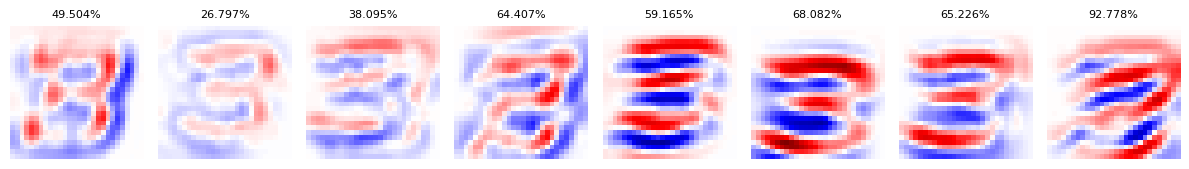

In [29]:
diff = fm_sv - fm
print("diff shape:", diff.shape)
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
v = diff.abs().max().item()
for i in range(8):
    a = fm[0, i].detach().cpu().numpy()
    b = fm_sv[0, i].detach().cpu().numpy()
    d = b - a
    rms = np.sqrt(np.mean(d**2))
    nrmse = rms / (np.sqrt(np.mean(a**2)) + 1e-12)
    axes[i].imshow(d, cmap="seismic", vmin=-v, vmax=v)
    axes[i].set_title(f"{100*nrmse:.3f}%", fontsize=8)
    axes[i].axis("off")
plt.tight_layout()
plt.show()

## 3) Array, Shift Invariant PSF ##

In [30]:
config.GRID_N = 115
config.HFOV=7
config.LENS_D=20*UM
config.PSF_WINDOW_N=115
config.SV=False

images shape: torch.Size([10, 16, 115, 115])


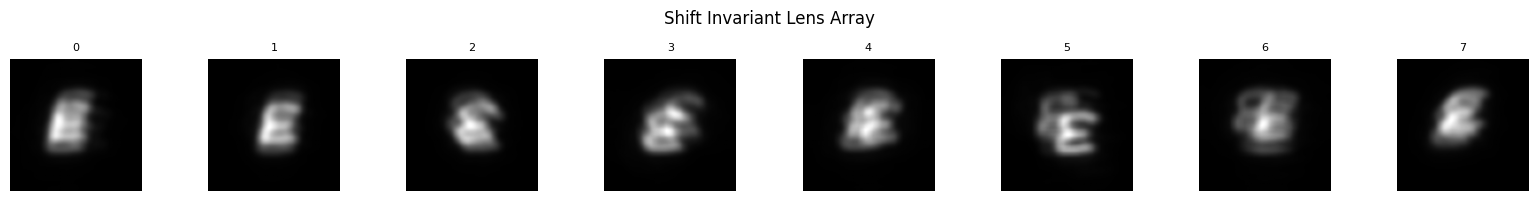

In [31]:
asm = ASMPropagator(config)
pm = PixelMap(config, asm.X, asm.Y)
waves = GenerateWaves(config, pm, X=asm.X, Y=asm.Y)
processor = PSFProcessor(config)
conv = PSFConv(config, pm, processor, asm.X, asm.Y)

pp = PostProcess(config, pixel_map=pm, X=asm.X, Y=asm.Y, mode="array")

array_phase = PhaseMask(
    config,
    init="custom",
    custom=array_phase_init,
    X=asm.X,
    Y=asm.Y,    
)

imager = FullOptForward(config, array_phase, asm, conv, pp, pm, waves, processor)

images = imager.optical_forward(objs)

print("images shape:", images.shape)
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i in range(8):
    axes[i].imshow(images[0, i].detach().cpu().numpy().T, cmap="gray", origin="lower")
    axes[i].set_title(f"{i}", fontsize=8)
    axes[i].axis("off")
plt.suptitle("Shift Invariant Lens Array")
plt.tight_layout()
plt.show()

fm shape: torch.Size([10, 8, 28, 28])


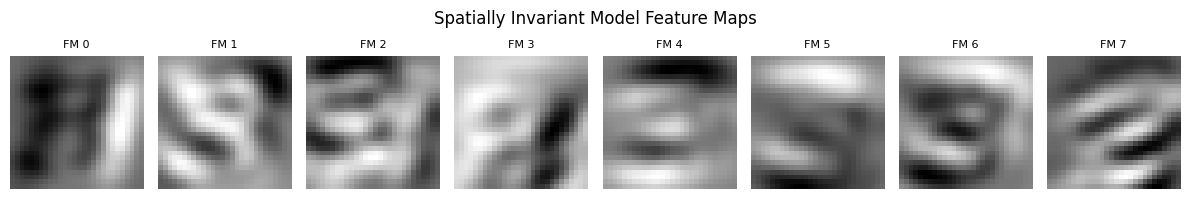

In [32]:
fm = imager.img2fm(images)
print("fm shape:", fm.shape)

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    axes[i].imshow(fm[0, i].detach().cpu().numpy(), cmap="gray")
    axes[i].set_title(f"FM {i}", fontsize=8)
    axes[i].axis("off")
plt.suptitle("Spatially Invariant Model Feature Maps")
plt.tight_layout()
plt.show()

## 4) Array, Spatially varying PSF ##

images shape: torch.Size([10, 16, 115, 115])


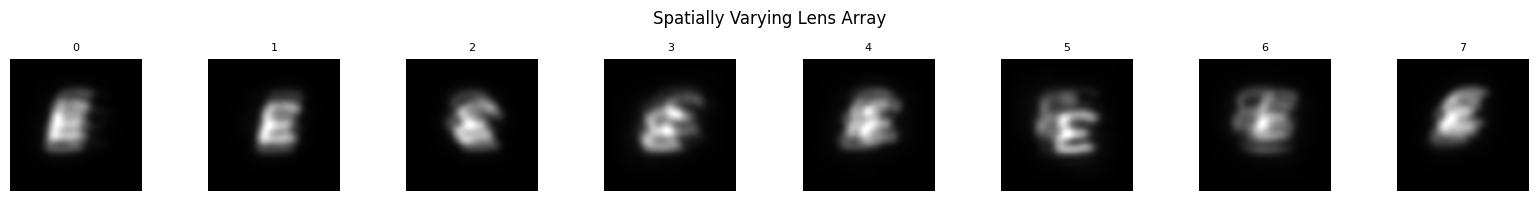

In [33]:
imager.config.SV=True
images_sv = imager.optical_forward(objs)


print("images shape:", images.shape)
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i in range(8):
    axes[i].imshow(images_sv[0, i].detach().cpu().numpy().T, cmap="gray", origin="lower")
    axes[i].set_title(f"{i}", fontsize=8)
    axes[i].axis("off")
plt.suptitle("Spatially Varying Lens Array")
plt.tight_layout()
plt.show()

fm shape: torch.Size([10, 8, 28, 28])


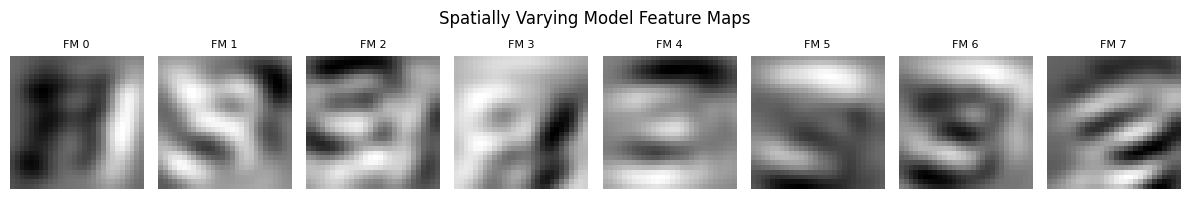

In [34]:
fm_sv = imager.img2fm(images_sv)
print("fm shape:", fm_sv.shape)

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    axes[i].imshow(fm_sv[0, i].detach().cpu().numpy(), cmap="gray")
    axes[i].set_title(f"FM {i}", fontsize=8)
    axes[i].axis("off")
plt.suptitle("Spatially Varying Model Feature Maps")
plt.tight_layout()
plt.show()

# Array -- difference between SI and SV ##

diff shape: torch.Size([10, 16, 115, 115])


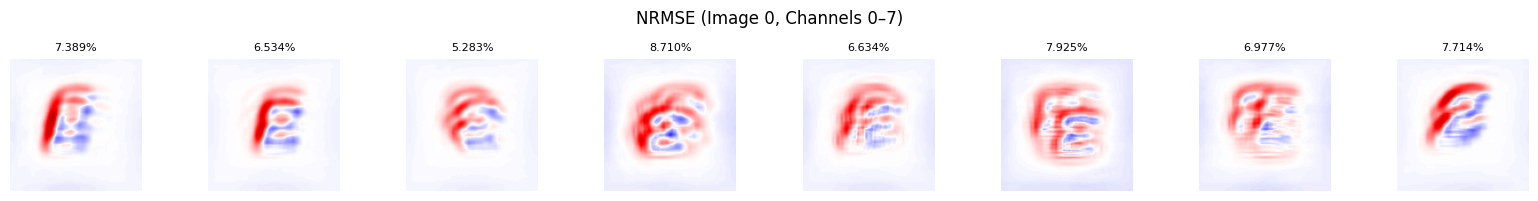

In [35]:
diff = images_sv - images
print("diff shape:", diff.shape)
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
v = diff.abs().max().item()
for i in range(8):
    a = images[0, i].detach().cpu().numpy()
    b = images_sv[0, i].detach().cpu().numpy()
    d = b - a
    rms = np.sqrt(np.mean(d**2))
    nrmse = rms / (np.sqrt(np.mean(a**2)) + 1e-12)
    axes[i].imshow(d.T, cmap="seismic", vmin=-v, vmax=v, origin="lower")
    axes[i].set_title(f"{100*nrmse:.3f}%", fontsize=8)
    axes[i].axis("off")
plt.suptitle("NRMSE (Image 0, Channels 0–7)")
plt.tight_layout()
plt.show()

diff shape: torch.Size([10, 8, 28, 28])


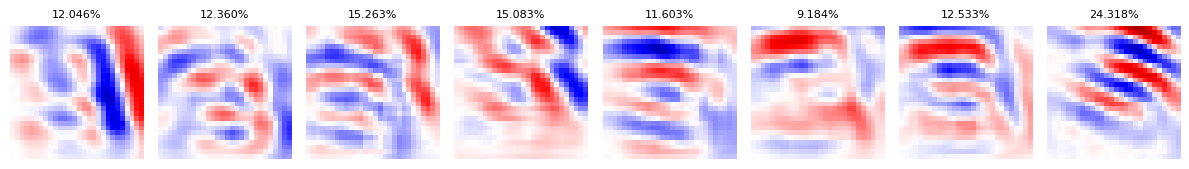

In [36]:
diff = fm_sv - fm
print("diff shape:", diff.shape)
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
v = diff.abs().max().item()
for i in range(8):
    a = fm[0, i].detach().cpu().numpy()
    b = fm_sv[0, i].detach().cpu().numpy()
    d = b - a
    rms = np.sqrt(np.mean(d**2))
    nrmse = rms / (np.sqrt(np.mean(a**2)) + 1e-12)
    axes[i].imshow(d, cmap="seismic", vmin=-v, vmax=v, origin="lower")
    axes[i].set_title(f"{100*nrmse:.3f}%", fontsize=8)
    axes[i].axis("off")
plt.tight_layout()
plt.show()